In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the uploaded Iris dataset
file_path = 'Iris.csv' 

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset successfully loaded into the dataframe!")
else:
    raise FileNotFoundError(f"Error: Could not find '{file_path}' in this folder. Please move the CSV file here.")

# Display the first 5 rows to confirm columns
df.head()


Dataset successfully loaded into the dataframe!


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
# Drop 'Id' column if it exists, as it is a unique identifier, not a machine learning feature
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("Dropped unnecessary 'Id' column.")

print("\n--- Missing Values Audit ---")
print(df.isnull().sum())

print("\n--- Dataset Summary Statistics ---")
df.describe()

Dropped unnecessary 'Id' column.

--- Missing Values Audit ---
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

--- Dataset Summary Statistics ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [13]:
# Automatically identify the target column name (e.g., 'Species' or 'species')
target_col = [col for col in df.columns if col.lower() == 'species'][0]

# Split into Features (X) and Target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Split data: 80% for training the model, 20% reserved for validation testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Feature Standardization (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split successfully. Training rows: {X_train.shape[0]} | Testing rows: {X_test.shape[0]}")

Data split successfully. Training rows: 120 | Testing rows: 30


In [14]:
# Initialize and fit the KNN model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)

# Generate predictions from validation test data
y_pred = knn_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("=========================================")
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")
print("=========================================\n")
print("--- Detailed Performance Classification Report ---")
print(classification_report(y_test, y_pred))

Final Model Accuracy: 100.00%

--- Detailed Performance Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



<Figure size 1000x600 with 0 Axes>

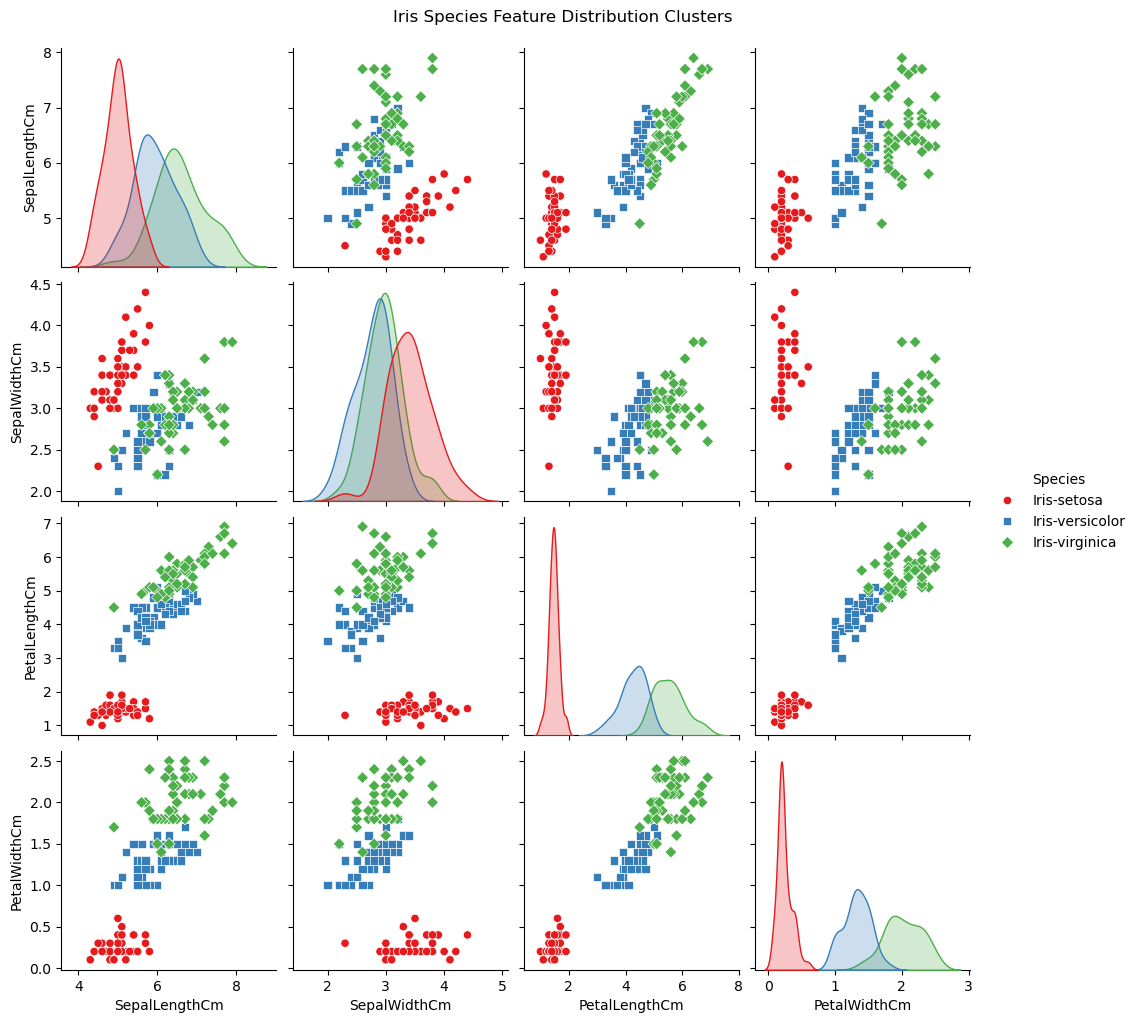

In [17]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue=target_col, palette='Set1', markers=["o", "s", "D"])
plt.suptitle("Iris Species Feature Distribution Clusters", y=1.02)


plt.savefig('iris_feature_clusters.png', dpi=300, bbox_inches='tight')
plt.show()